In [1]:
# 1. Install necessary libraries
!pip install rasterio shapely matplotlib numpy torch torchvision

import os
import json
import rasterio
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from rasterio import features
from rasterio.windows import Window
import random

# Device configuration (MPS for Mac, CUDA for PC, else CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: mps


In [2]:
import glob

# Base Directory Setup
BASE_PATH = "/Users/shashank/Building_Damage_Project"
RAW_DIR = os.path.join(BASE_PATH, "raw_data")
OUT_DIR = os.path.join(BASE_PATH, "output_tiles_v3")

# Automatically find all TIF files in the folder
tif_files = sorted(glob.glob(os.path.join(RAW_DIR, "MussettBayouFire-*.tif")))

print(f"📂 Found {len(tif_files)} GeoTIFF files for processing.")

📂 Found 5 GeoTIFF files for processing.


In [3]:
import shutil

# Check if the folder exists, and if so, delete it to start fresh
if os.path.exists(OUT_DIR):
    print(f"🧹 Cleaning up old data in {OUT_DIR}...")
    shutil.rmtree(OUT_DIR)

# Re-create the empty folders
os.makedirs(os.path.join(OUT_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "masks"), exist_ok=True)

🧹 Cleaning up old data in /Users/shashank/Building_Damage_Project/output_tiles_v3...


In [ ]:
# 1. Prepare Output Folders
os.makedirs(os.path.join(OUT_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "masks"), exist_ok=True)

tile_size = 512
stride = 256  # Keeping the 50% overlap fix!

# 2. Loop through every image found
for tif_path in tif_files:
    file_id = os.path.basename(tif_path).replace("_tif.tif", "")
    base_json = os.path.join(RAW_DIR, f"{file_id}_json.json")
    align_json = os.path.join(RAW_DIR, f"{file_id}_json_aligned.json")
    
    print(f"🛠️ Processing {file_id}...")

    # Calculate Shift for this specific image
    with open(align_json) as f:
        align_data = json.load(f)
    shift_x = np.mean([pair[1][0] - pair[0][0] for pair in align_data])
    shift_y = np.mean([pair[1][1] - pair[0][1] for pair in align_data])

    with rasterio.open(tif_path) as src:
        img_transform = src.transform
        h, w = src.height, src.width

        # Project Polygons for this specific image
        with open(base_json) as f:
            base_data = json.load(f)

        projected_polygons = []
        for entry in base_data:
            if 'pixels' in entry:
                coords = [(p['x'] + shift_x, p['y'] + shift_y) for p in entry['pixels']]
                world_coords = [img_transform * (x, y) for x, y in coords]
                projected_polygons.append(Polygon(world_coords))

        # Tile this specific image
        for y in range(0, h - tile_size, stride):
            for x in range(0, w - tile_size, stride):
                window = Window(x, y, tile_size, tile_size)
                mask_patch = features.rasterize(
                    shapes=projected_polygons,
                    out_shape=(tile_size, tile_size),
                    transform=src.window_transform(window),
                    fill=0, default_value=255, dtype=np.uint8
                )

                if np.any(mask_patch == 255): 
                    img_patch = src.read([1, 2, 3], window=window)
                    # Unique ID: filename + coordinates
                    tile_name = f"{file_id}_y{y}_x{x}.png"
                    plt.imsave(os.path.join(OUT_DIR, "images", tile_name), img_patch.transpose(1, 2, 0))
                    plt.imsave(os.path.join(OUT_DIR, "masks", tile_name), mask_patch, cmap='gray')

print(f"✅ Finished! Check {OUT_DIR} for your combined tile library.")

🛠️ Processing MussettBayouFire-01...
🛠️ Processing MussettBayouFire-02...
🛠️ Processing MussettBayouFire-03...
🛠️ Processing MussettBayouFire-04...
🛠️ Processing MussettBayouFire-05...


In [5]:
FINAL_DATASET = os.path.join(BASE_PATH, "final_dataset_v3")

# Create folder structure
for s in ['train', 'val', 'test']:
    for sub in ['images', 'masks']:
        os.makedirs(os.path.join(FINAL_DATASET, s, sub), exist_ok=True)

all_images = os.listdir(os.path.join(OUT_DIR, "images"))
random.shuffle(all_images)

# Split ratios: 80% Train, 15% Val, 5% Test
n = len(all_images)
train_files = all_images[:int(n*0.8)]
val_files = all_images[int(n*0.8):int(n*0.95)]
test_files = all_images[int(n*0.95):]

def move_data(files, split):
    for f in files:
        shutil.copy(os.path.join(OUT_DIR, "images", f), os.path.join(FINAL_DATASET, split, "images", f))
        shutil.copy(os.path.join(OUT_DIR, "masks", f), os.path.join(FINAL_DATASET, split, "masks", f))

move_data(train_files, 'train'); move_data(val_files, 'val'); move_data(test_files, 'test')
print(f"✅ Split complete: {len(train_files)} Train, {len(val_files)} Val, {len(test_files)} Test")

✅ Split complete: 2114 Train, 396 Val, 133 Test


In [8]:
import os
from torch.utils.data import DataLoader

# 1. Setup the Directories (Ensure these match your path)
FINAL_DATASET = "/Users/shashank/Building_Damage_Project/final_dataset_v3"

# 2. Initialize the Datasets
# We use 'augment=True' for training to make the model more robust
train_ds = BuildingDataset(FINAL_DATASET, 'train', augment=True)
val_ds = BuildingDataset(FINAL_DATASET, 'val', augment=False)

# 3. Define the Loaders
# This actually creates the 'train_loader' variable the training loop is looking for
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print(f"✅ train_loader and val_loader are now defined and ready!")

✅ train_loader and val_loader are now defined and ready!


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

class BuildingDataset(Dataset):
    def __init__(self, root, split, augment=False):
        self.img_dir = os.path.join(root, split, "images")
        self.mask_dir = os.path.join(root, split, "masks")
        self.files = sorted(os.listdir(self.img_dir))
        self.augment = augment

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.files[idx])).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, self.files[idx])).convert("L")
        
        if self.augment: # Random flips for diversity
            if random.random() > 0.5: img = T.functional.hflip(img); mask = T.functional.hflip(mask)
            if random.random() > 0.5: img = T.functional.vflip(img); mask = T.functional.vflip(mask)

        return T.ToTensor()(img), (T.ToTensor()(mask) > 0).float()

class UNet(nn.Module): # Architecture with skip connections
    def __init__(self):
        super().__init__()
        def conv(i, o): return nn.Sequential(nn.Conv2d(i, o, 3, 1, 1), nn.ReLU(True), nn.Conv2d(o, o, 3, 1, 1), nn.ReLU(True))
        self.e1=conv(3,64); self.e2=conv(64,128); self.e3=conv(128,256); self.e4=conv(256,512)
        self.u3=nn.ConvTranspose2d(512,256,2,2); self.d3=conv(512,256)
        self.u2=nn.ConvTranspose2d(256,128,2,2); self.d2=conv(256,128)
        self.u1=nn.ConvTranspose2d(128,64,2,2); self.d1=conv(128,64)
        self.out=nn.Conv2d(64,1,1)

    def forward(self, x):
        c1=self.e1(x); c2=self.e2(F.max_pool2d(c1,2)); c3=self.e3(F.max_pool2d(c2,2)); c4=self.e4(F.max_pool2d(c3,2))
        x=self.d3(torch.cat([self.u3(c4),c3],1)); x=self.d2(torch.cat([self.u2(x),c2],1)); x=self.d1(torch.cat([self.u1(x),c1],1))
        return self.out(x)

model = UNet().to(device)


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# 1. Define the Dice Loss Class
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        dice_coeff = (2. * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1. - dice_coeff

# 2. Re-initialize Model, Optimizer, and Scheduler
model = UNet().to(device)
criterion = DiceLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# REMOVED: verbose=True (Not supported in new PyTorch versions)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# 3. Enhanced Training Loop
NUM_EPOCHS = 100 

print("🎓 Starting Enhanced Training with Dice Loss...")

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    # Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            v_loss = criterion(outputs, masks)
            val_loss += v_loss.item()
            
    # Step the scheduler based on validation loss
    scheduler.step(val_loss)
    
    # MANUAL VERBOSE: Check and print current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f}")

# 4. Save the "Best Model" weights
checkpoint_path = "/Users/shashank/Building_Damage_Project/unet_building_dice_v3.pth"
torch.save(model.state_dict(), checkpoint_path)
print(f"✅ Training complete! Weights saved to: {checkpoint_path}")

# 4. Save the "Best Model" weights
# checkpoint_path = "/Users/shashank/Building_Damage_Project/unet_building_dice_v3.pth"

🎓 Starting Enhanced Training with Dice Loss...
Epoch [1/100] | Train Loss: 0.5221 | Val Loss: 0.5251 | LR: 0.000100
Epoch [2/100] | Train Loss: 0.5153 | Val Loss: 0.5251 | LR: 0.000100
Epoch [3/100] | Train Loss: 0.5148 | Val Loss: 0.5251 | LR: 0.000100
Epoch [4/100] | Train Loss: 0.5153 | Val Loss: 0.5251 | LR: 0.000100
Epoch [5/100] | Train Loss: 0.5148 | Val Loss: 0.5251 | LR: 0.000100
Epoch [6/100] | Train Loss: 0.5145 | Val Loss: 0.5251 | LR: 0.000100
Epoch [7/100] | Train Loss: 0.5160 | Val Loss: 0.5251 | LR: 0.000050
Epoch [8/100] | Train Loss: 0.5142 | Val Loss: 0.5251 | LR: 0.000050
Epoch [9/100] | Train Loss: 0.5157 | Val Loss: 0.5251 | LR: 0.000050
Epoch [10/100] | Train Loss: 0.5148 | Val Loss: 0.5251 | LR: 0.000050
Epoch [11/100] | Train Loss: 0.5163 | Val Loss: 0.5251 | LR: 0.000050
Epoch [12/100] | Train Loss: 0.5146 | Val Loss: 0.5251 | LR: 0.000050
Epoch [13/100] | Train Loss: 0.5155 | Val Loss: 0.5251 | LR: 0.000025
Epoch [14/100] | Train Loss: 0.5150 | Val Loss: 0.52

--- 📈 Final Performance Results ---
Mean IoU: 0.3488
Mean F1-Score (Dice): 0.4531
-----------------------------------


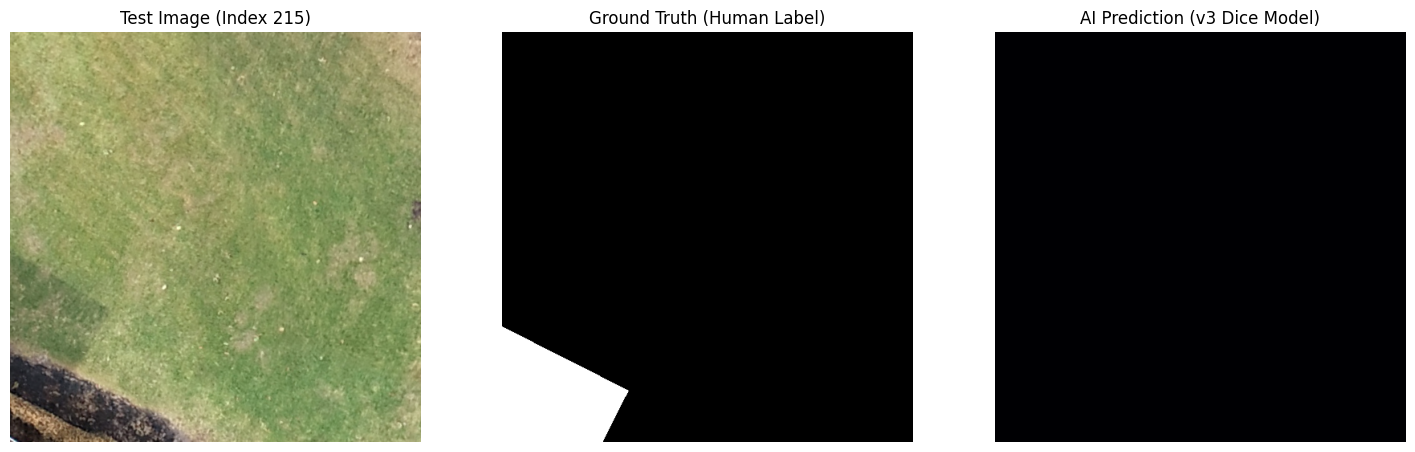

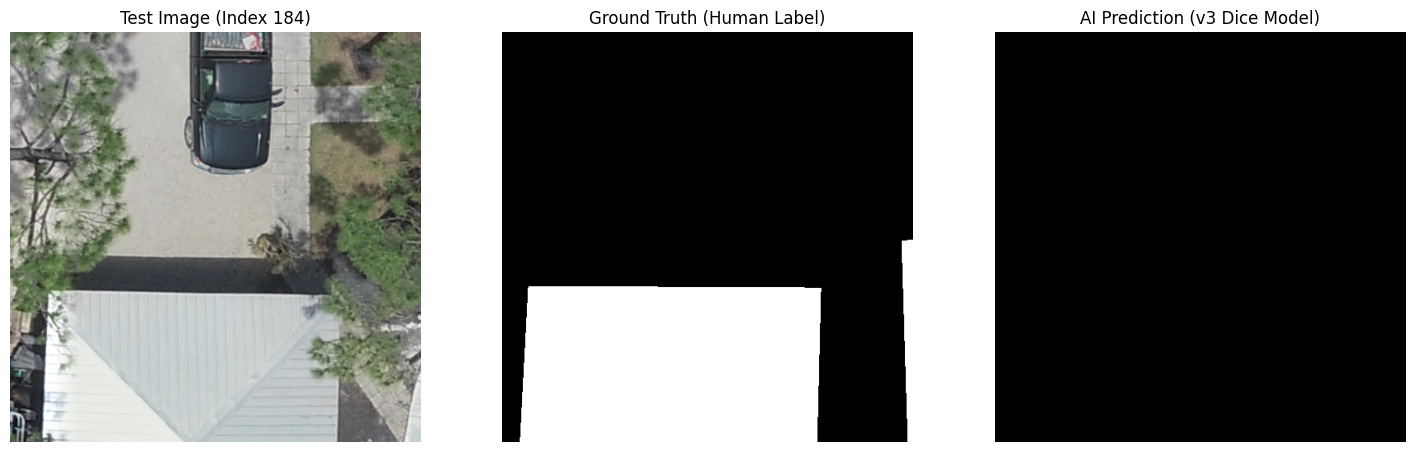

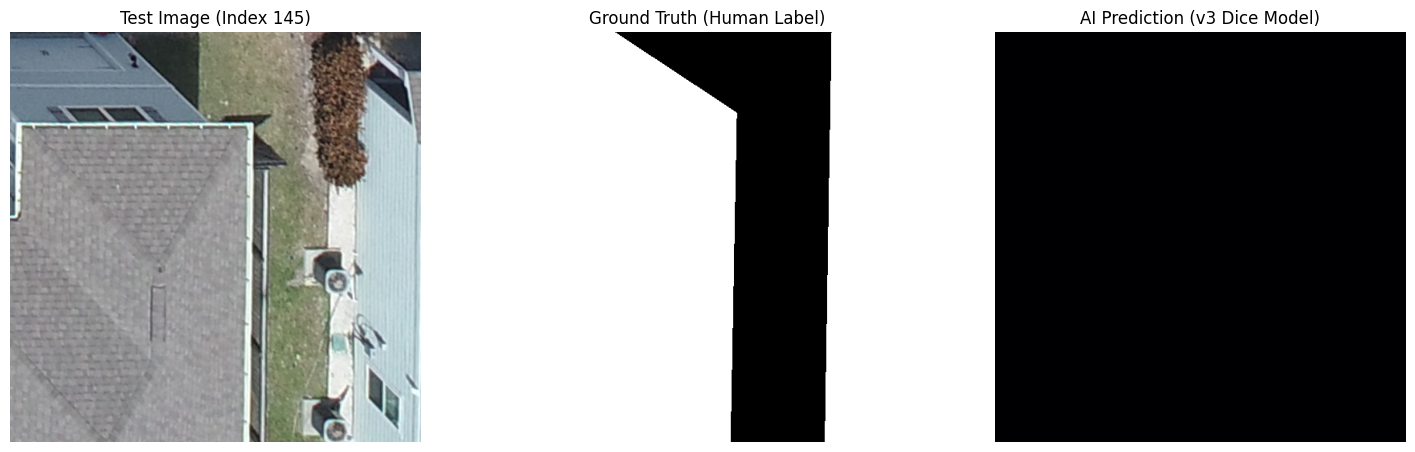

In [10]:
import random
import matplotlib.pyplot as plt

def evaluate_and_visualize(model, dataset, num_samples=3):
    model.eval()
    ious = []
    f1_scores = []
    
    # 1. Calculate Metrics on the entire Test Set
    with torch.no_grad():
        for i in range(len(dataset)):
            img, mask = dataset[i]
            img_input = img.unsqueeze(0).to(device)
            mask = mask.to(device)
            
            output = torch.sigmoid(model(img_input))
            pred = (output > 0.5).float()
            
            # Intersection and Union calculation
            intersection = (pred * mask).sum()
            union = (pred + mask).sum() - intersection
            
            iou = (intersection + 1e-6) / (union + 1e-6)
            f1 = (2 * intersection + 1e-6) / (pred.sum() + mask.sum() + 1e-6)
            
            ious.append(iou.item())
            f1_scores.append(f1.item())

    print(f"--- 📈 Final Performance Results ---")
    print(f"Mean IoU: {np.mean(ious):.4f}")
    print(f"Mean F1-Score (Dice): {np.mean(f1_scores):.4f}")
    print("-" * 35)

    # 2. Visualize Random Samples
    indices = random.sample(range(len(dataset)), num_samples)
    
    for idx in indices:
        img, mask = dataset[idx]
        img_input = img.unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = torch.sigmoid(model(img_input))
            pred = (output > 0.5).squeeze().cpu().numpy()
        
        fig, ax = plt.subplots(1, 3, figsize=(18, 6))
        
        # Display Input Drone Image
        ax[0].imshow(img.permute(1, 2, 0))
        ax[0].set_title(f"Test Image (Index {idx})")
        ax[0].axis('off')
        
        # Display Human Ground Truth
        ax[1].imshow(mask.squeeze(), cmap='gray')
        ax[1].set_title("Ground Truth (Human Label)")
        ax[1].axis('off')
        
        # Display AI Prediction
        ax[2].imshow(pred, cmap='magma')
        ax[2].set_title(f"AI Prediction (v3 Dice Model)")
        ax[2].axis('off')
        
        plt.show()

# Run the evaluation on the 'test' split
test_ds = BuildingDataset(FINAL_DATASET, 'test', augment=False)
evaluate_and_visualize(model, test_ds)

In [4]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class BuildingDataset(Dataset):

    def __init__(self, data_dir="../train_data"):
        self.img_dir = os.path.join(data_dir, "images")
        self.mask_dir = os.path.join(data_dir, "masks")
        self.files = [f for f in os.listdir(self.img_dir) if f.endswith(".npy")]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        img = np.load(os.path.join(self.img_dir, self.files[idx])).astype(np.float32)/255.0
        mask = np.load(os.path.join(self.mask_dir, self.files[idx])).astype(np.float32)

        img = torch.from_numpy(img).permute(2,0,1)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return img, mask

In [5]:
dataset = BuildingDataset()

In [8]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_subset, test_subset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [9]:
import torch
import numpy as np
from tqdm import tqdm
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader

# -----------------------------
# 1. LOAD MODEL
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = "/Users/shashank/Building_Damage_Project/unet_building_dice_v3.pth"

model = UNet().to(device)

checkpoint_path = "/Users/shashank/Building_Damage_Project/unet_building_dice_v3.pth"

model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()

print("✅ Model loaded successfully")


# -----------------------------
# 2. TEST LOADER
# Use same dataset split you used in training
# -----------------------------
test_loader = DataLoader(test_subset, batch_size=1, shuffle=False)


# -----------------------------
# 3. METRIC CALCULATION
# -----------------------------
def evaluate_metrics(loader, model, threshold=0.5):

    tp = fp = fn = tn = 0.0

    print(f"🧐 Evaluating {len(loader)} unseen tiles...")

    with torch.no_grad():
        for images, masks in tqdm(loader):

            images = images.to(device)

            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            masks = masks.to(device).float()

            outputs = model(images)

            preds = (outputs > threshold).float()

            tp += (preds * masks).sum().item()
            fp += (preds * (1 - masks)).sum().item()
            fn += ((1 - preds) * masks).sum().item()
            tn += ((1 - preds) * (1 - masks)).sum().item()

    eps = 1e-7

    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)

    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)

    f1 = (2 * precision * recall) / (precision + recall + eps)

    specificity = tn / (tn + fp + eps)

    balanced_acc = 0.5 * (recall + specificity)

    overall_acc = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "IoU": iou,
        "Dice": dice,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "Balanced Accuracy": balanced_acc,
        "Overall Accuracy": overall_acc
    }


# -----------------------------
# 4. RUN EVALUATION
# -----------------------------
metrics = evaluate_metrics(test_loader, model)


# -----------------------------
# 5. PRINT RESULTS
# -----------------------------
print("\n--- 🌍 GLOBAL DISASTER FOUNDATION RESULTS ---")

print(f"IoU               : {metrics['IoU']:.4f}")
print(f"Dice              : {metrics['Dice']:.4f}")
print(f"Precision         : {metrics['Precision']:.4f}")
print(f"Recall (Target)   : {metrics['Recall']:.4f}")
print(f"F1-score          : {metrics['F1']:.4f}")
print(f"Specificity       : {metrics['Specificity']:.4f}")
print(f"Balanced Acc.     : {metrics['Balanced Accuracy']:.4f}")
print(f"Overall Accuracy  : {metrics['Overall Accuracy']:.4f}")

✅ Model loaded successfully
🧐 Evaluating 13526 unseen tiles...


100%|███████████████████████████████████████████████████████████████████████████| 13526/13526 [2:30:44<00:00,  1.50it/s]


--- 🌍 GLOBAL DISASTER FOUNDATION RESULTS ---
IoU               : 0.3129
Dice              : 0.4767
Precision         : 0.3129
Recall (Target)   : 1.0000
F1-score          : 0.4767
Specificity       : 0.0000
Balanced Acc.     : 0.5000
Overall Accuracy  : 0.3129


In [2]:
import torch
import torch.nn as nn

class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.e1 = self.block(3,64)
        self.e2 = self.block(64,128)
        self.e3 = self.block(128,256)
        self.e4 = self.block(256,512)

        self.pool = nn.MaxPool2d(2)

        self.u3 = nn.ConvTranspose2d(512,256,2,2)
        self.d3 = self.block(512,256)

        self.u2 = nn.ConvTranspose2d(256,128,2,2)
        self.d2 = self.block(256,128)

        self.u1 = nn.ConvTranspose2d(128,64,2,2)
        self.d1 = self.block(128,64)

        self.out = nn.Conv2d(64,1,1)

    def block(self,in_c,out_c):
        return nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.ReLU()
        )

    def forward(self,x):

        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))

        d3 = self.u3(e4)
        d3 = torch.cat([d3,e3],1)
        d3 = self.d3(d3)

        d2 = self.u2(d3)
        d2 = torch.cat([d2,e2],1)
        d2 = self.d2(d2)

        d1 = self.u1(d2)
        d1 = torch.cat([d1,e1],1)
        d1 = self.d1(d1)

        return torch.sigmoid(self.out(d1))